In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

2024-08-26 15:27:22.825683: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-26 15:27:22.834960: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-26 15:27:22.845512: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-26 15:27:22.848563: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-26 15:27:22.857193: I tensorflow/core/platform/cpu_feature_guar

In [16]:
iz = 128
bs = 32

In [17]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Datasets/Die_1",
    shuffle = True,
    seed = 16,
    image_size = (iz, iz),
    batch_size = bs
)

Found 1140 files belonging to 2 classes.


In [18]:
class_names = dataset.class_names
class_number = len(class_names)
print (class_names, class_number)

['Not_OK', 'OK'] 2


In [19]:
for images, labels in dataset.take(1):
    print(images.shape, labels.shape)
    print(images.dtype, labels.dtype)

(32, 128, 128, 3) (32,)
<dtype: 'float32'> <dtype: 'int32'>


In [20]:
for images, labels in dataset.take(1):
    print(images.shape)
    print(labels.numpy())

(32, 128, 128, 3)
[0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1]


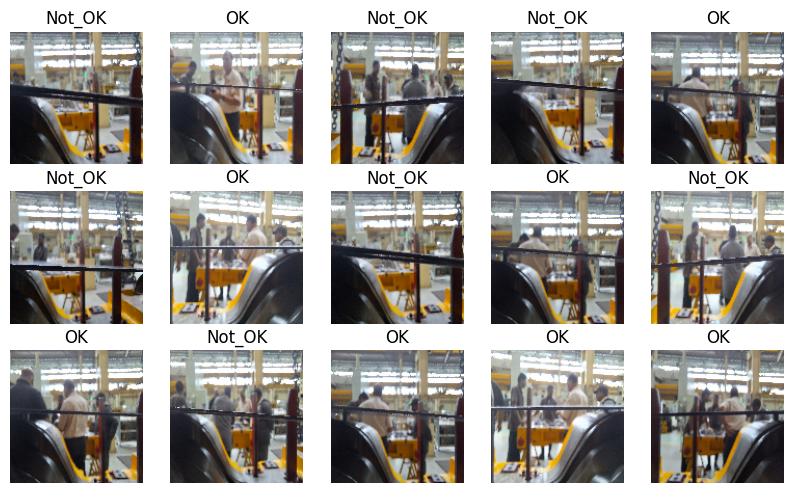

In [21]:
plt.figure(figsize=(10, 10))        

for images, labels in dataset.take(1):  
    for i in range(15):           
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off") 

In [22]:
ts = int(len(dataset)*0.8)
vs = int(len(dataset)*0.1)
print("Total lenght of dataset : ", len(dataset))
print("80% for training : ", int(len(dataset)*0.8))
print("10% for validation : ", int(len(dataset)*0.1))
print("10% for testing : ", int(len(dataset) - (int(len(dataset)*0.8) + int(len(dataset)*0.1))))

Total lenght of dataset :  36
80% for training :  28
10% for validation :  3
10% for testing :  5


In [23]:
training_ds = dataset.take(ts)
remaining_ds = dataset.skip(ts)
validation_ds = remaining_ds.take(vs)
testing_ds = remaining_ds.skip(vs)

print("Lenght of training dataset : ", len(training_ds))
print("Lenght of validation dataset : ", len(validation_ds))
print("Lenght of testing dataset : ", len(testing_ds))

Lenght of training dataset :  28
Lenght of validation dataset :  3
Lenght of testing dataset :  5


In [24]:
from tensorflow.keras.applications import VGG16

model = models.Sequential()
model.add(VGG16(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='softmax'))
model.layers[0].trainable = True

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,714 (56.14 MB)

 Trainable params: 14,715,714 (56.14 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
early = EarlyStopping(monitor = 'val_accuracy', patience=5)

In [28]:
history_1 = model.fit(training_ds, epochs=100, validation_data=validation_ds, callbacks=early)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5281 - loss: 214.5605

2024-08-26 15:32:55.837926: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


28/28 ━━━━━━━━━━━━━━━━━━━━ 267s 9s/step - accuracy: 0.5271 - loss: 210.0257 - val_accuracy: 0.6562 - val_loss: 0.6835
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 529ms/step - accuracy: 0.5135 - loss: 0.7298 - val_accuracy: 0.4479 - val_loss: 0.6901
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - accuracy: 0.5103 - loss: 0.6979 - val_accuracy: 0.4896 - val_loss: 0.6897
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.6050 - loss: 0.6777 - val_accuracy: 0.4896 - val_loss: 0.6414
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.6347 - loss: 0.5203 - val_accuracy: 0.9271 - val_loss: 0.1282
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.9536 - loss: 0.0995 - val_accuracy: 1.0000 - val_loss: 0.0145
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 1.4624e-04
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 1.0000 - loss: 2.6195e-04 - val_accura

In [29]:
scores_1 = model.evaluate(testing_ds)
scores_1

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 499ms/step - accuracy: 1.0000 - loss: 1.2760e-05


[1.5243057532643434e-05, 1.0]

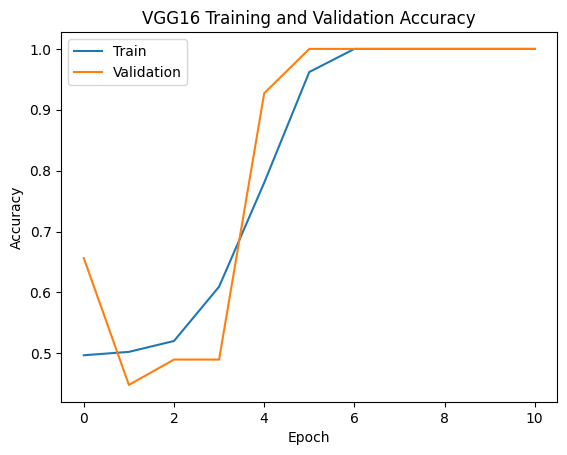

In [30]:
# Plot training and validation accuracy
plt.plot(history_1.history['accuracy'], label='Train')
plt.plot(history_1.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('VGG16 Training and Validation Accuracy')
plt.show()

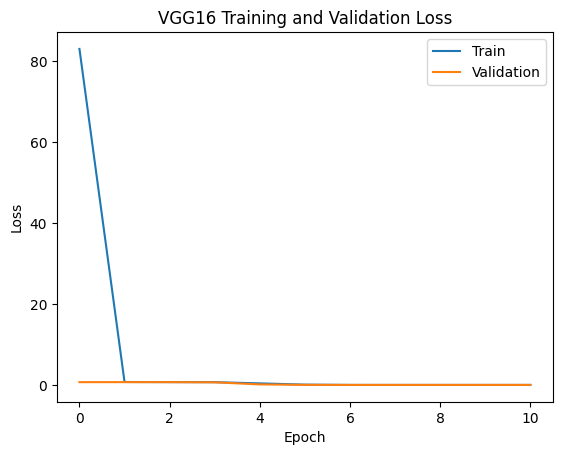

In [31]:
# Plot training and validation accuracy
plt.plot(history_1.history['loss'], label='Train')
plt.plot(history_1.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('VGG16 Training and Validation Loss')
plt.show()

2024-08-26 15:34:46.694423: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


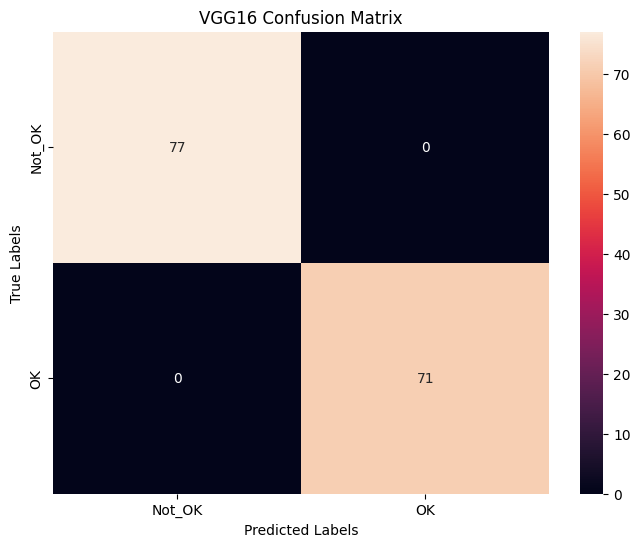

In [32]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(predictions, axis=1))

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('VGG16 Confusion Matrix')
plt.show()


In [33]:
conf_matrix

array([[77,  0],
       [ 0, 71]])

In [ ]:
# model.save(f"Models/VGG16")

In [34]:
from tensorflow.keras.applications import ResNet50

model = models.Sequential()
model.add(ResNet50(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='softmax'))
model.layers[0].trainable = True

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 346s 4us/step


In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 23,538,690 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [36]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [37]:
early = EarlyStopping(monitor = 'val_accuracy', patience=5)

In [38]:
history_2 = model.fit(training_ds, epochs=100, validation_data=validation_ds, callbacks=early)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 43s 265ms/step - accuracy: 0.8703 - loss: 1.7658 - val_accuracy: 0.3854 - val_loss: 6272.1304
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.9942 - loss: 0.0301 - val_accuracy: 0.6354 - val_loss: 9339.2100
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.9888 - loss: 0.0534 - val_accuracy: 0.4688 - val_loss: 4195.6567
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8958 - val_loss: 43.4890
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 1.0000 - loss: 1.0828e-04 - val_accuracy: 0.9896 - val_loss: 0.0311
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 1.0000 - loss: 6.5447e-05 - val_accuracy: 1.0000 - val_loss: 9.5490e-07
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 1.0000 - loss: 1.1145e-04 - val_accuracy: 1.0000 - val_loss: 7.2649e-06
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 1

In [39]:
scores_2 = model.evaluate(testing_ds)
scores_2

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 609ms/step - accuracy: 1.0000 - loss: 3.3538e-06


[3.295001761216554e-06, 1.0]

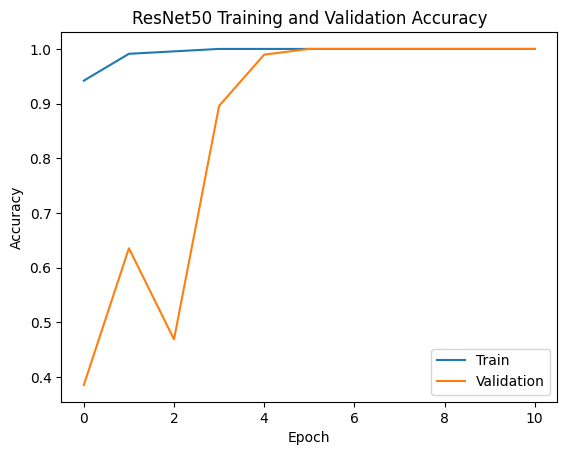

In [40]:
# Plot training and validation accuracy
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet50 Training and Validation Accuracy')
plt.show()

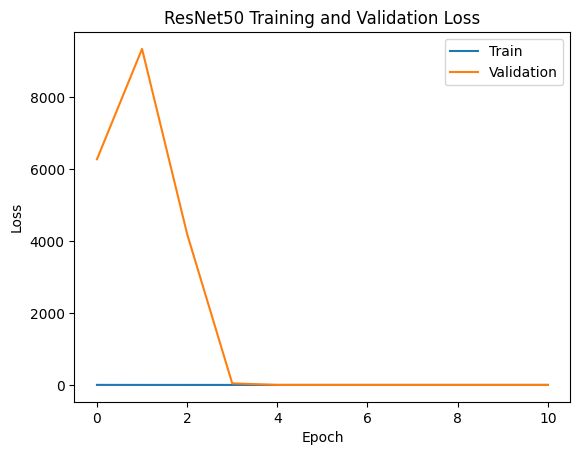

In [41]:
# Plot training and validation accuracy
plt.plot(history_2.history['loss'], label='Train')
plt.plot(history_2.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('ResNet50 Training and Validation Loss')
plt.show()

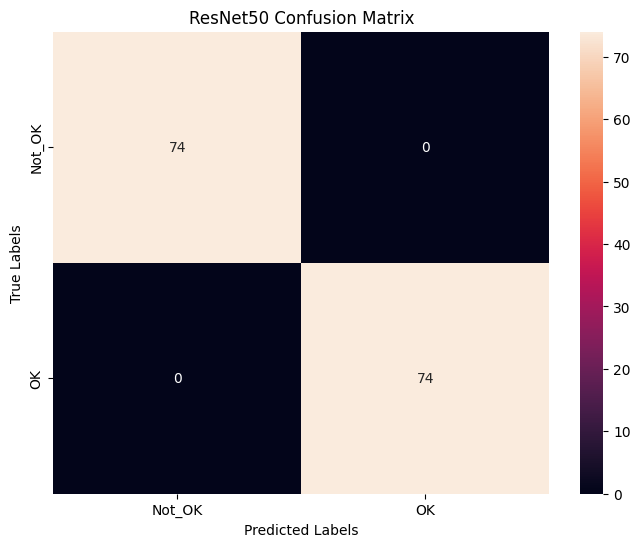

In [42]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(predictions, axis=1))

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('ResNet50 Confusion Matrix')
plt.show()


In [43]:
conf_matrix

array([[74,  0],
       [ 0, 74]])

In [ ]:
# model.save(f"Models/ResNet50")

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B3

model = models.Sequential()
model.add(EfficientNetV2B3(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='softmax'))
model.layers[0].trainable = True

In [ ]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 dense_5 (Dense)             (None, 2)                 3074      
                                                                 
Total params: 12,933,696
Trainable params: 12,824,480
Non-trainable params: 109,216
_________________________________________________________________


In [ ]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
early = EarlyStopping(monitor = 'val_accuracy', patience=5)

In [ ]:
history_3 = model.fit(training_ds, epochs=100, validation_data=validation_ds, callbacks=early)

Epoch 1/100


ResourceExhaustedError: Graph execution error:

Detected at node 'sequential_5/efficientnetv2-b3/block5c_bn/FusedBatchNormV3' defined at (most recent call last):
    File "c:\Users\baldo\.conda\envs\gpu2\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\baldo\.conda\envs\gpu2\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\Users\baldo\.conda\envs\gpu2\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "c:\Users\baldo\.conda\envs\gpu2\lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
      app.start()
    File "c:\Users\baldo\.conda\envs\gpu2\lib\site-packages\ipykernel\kernelapp.py", line 701, in start
      self.io_loop.start()
    File "c:\Users\baldo\.conda\envs\gpu2\lib\site-packages\tornado\platform\asyncio.py", line 195, in start
      self.asyncio_loop.run_forever()
    File "c:\Users\baldo\.conda\en

In [ ]:
scores_3 = model.evaluate(testing_ds)
scores_3

5/5 [==============================] - 4s 112ms/step - loss: 0.6884 - accuracy: 0.5743


[0.6884033679962158, 0.5743243098258972]

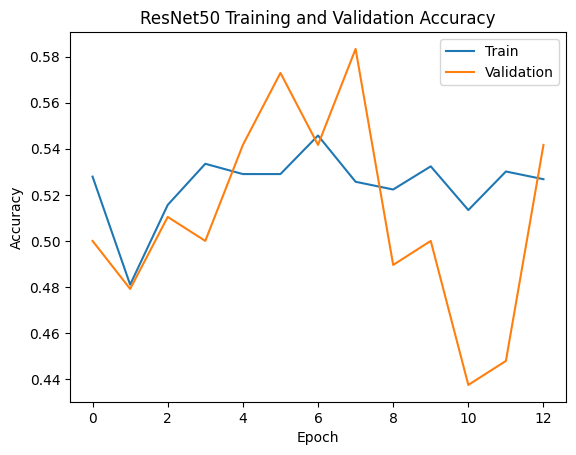

In [ ]:
# Plot training and validation accuracy
plt.plot(history_3.history['accuracy'], label='Train')
plt.plot(history_3.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('EfficientNetV2B3 Training and Validation Accuracy')
plt.show()

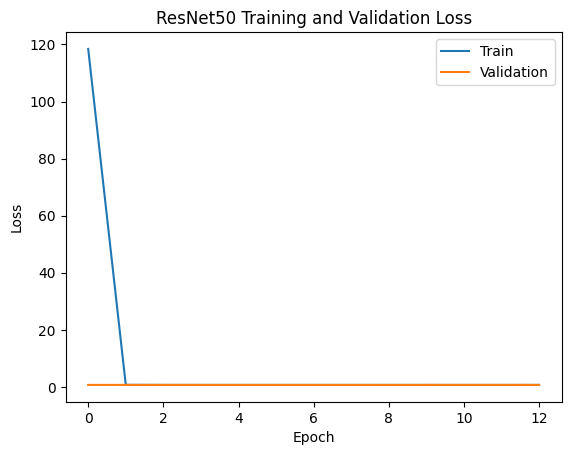

In [ ]:
# Plot training and validation accuracy
plt.plot(history_3.history['loss'], label='Train')
plt.plot(history_3.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('EfficientNetV2B3 Training and Validation Loss')
plt.show()

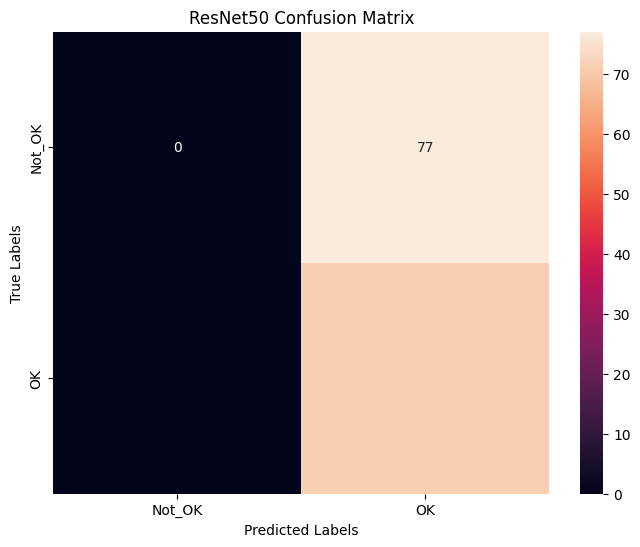

In [ ]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(predictions, axis=1))

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('EfficientNetV2B3 Confusion Matrix')
plt.show()


In [ ]:
conf_matrix

array([[ 0, 77],
       [ 0, 71]], dtype=int64)

In [ ]:
# model.save(f"Models/ResNet50")